In [10]:
from rdkit.ML.Descriptors import MoleculeDescriptors
from library import preprocess_smiles
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
from rdkit import Chem
import pandas as pd
import json

In [2]:
DATA_SOURCE = "../data/AqSolDB/data_curated.csv"

In [3]:
df = pd.read_csv(DATA_SOURCE)

# preprocess the smiles for the quantumFP program
preprocessed_smiles = [preprocess_smiles(smiles) for smiles in df["SMILES"]]

print(len(preprocessed_smiles))

cleaned_smiles = []
solubilities = []
db_ids = []
for idx, smiles in enumerate(preprocessed_smiles):
    if smiles is not None:
        cleaned_smiles.append(smiles)
        db_ids.append(df.iloc[idx]["ID"])
        solubilities.append(df.iloc[idx]["Solubility"])

# Filter out all None instances returned from preprocess_smiles
# cleaned_smiles = list(filter(lambda x: x is not None, preprocessed_smiles))

[16:51:40] WARNING: not removing hydrogen atom without neighbors
[16:51:40] WARNING: not removing hydrogen atom without neighbors
[16:51:40] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not removing hydrogen atom without neighbors
[16:51:41] WARNING: not r

9982


In [4]:
feature_df = pd.DataFrame({"db_id": db_ids, "smiles": cleaned_smiles, "Solubility": solubilities})

mols = [Chem.MolFromSmiles(smiles) for smiles in feature_df["smiles"]]
feature_df['num_heavy_atoms'] = pd.DataFrame(
    [mol.GetNumHeavyAtoms() for mol in mols]
)

feature_df

,db_id,smiles,Solubility,num_heavy_atoms
0,A-4,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,-3.254767,13
1,A-5,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,-2.177078,9
2,A-9,[C:1]1([H:32])([H:33])[O:2][C:3]1([C:4]([N:5](...,-4.662065,31
3,A-10,[C:1]([c:2]1[c:3]([H:13])[c:4]([H:14])[c:5]([H...,-3.123150,9
4,A-11,[C:1]([C:2]([C:3]1([H:18])[C:4]([H:19])([H:20]...,-3.286116,12
...,...,...,...,...
8840,I-84,[C:1]([c:2]1[c:3]([H:20])[c:4]([H:21])[c:5]([N...,-3.010000,19
8841,I-85,[O:1]([c:2]1[c:3]2[c:29]([c:30]([H:54])[c:31](...,-2.930000,32
8842,I-86,[c:1]1([O:11][H:25])[c:2]([H:12])[c:3]([C:10](...,-2.190000,11
8843,I-93,[C:1]([O:2][c:3]1[c:4]([H:37])[c:5]([H:38])[c:...,-3.980000,33


In [12]:
descriptor_names = [name for name, _ in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
descriptor_names

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


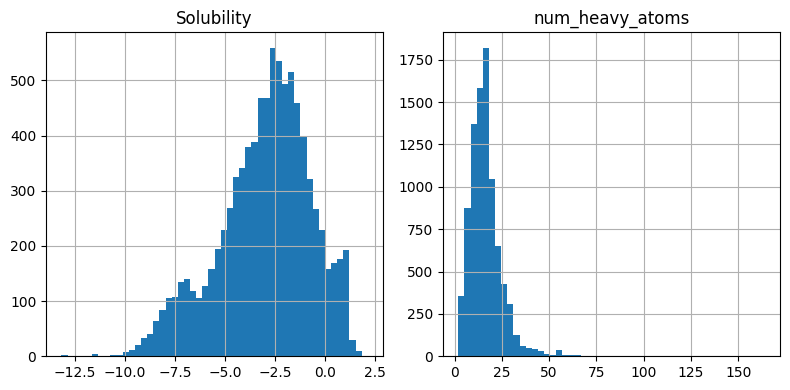

In [8]:
subset_cols = ["Solubility", "num_heavy_atoms"]
subset_feature_df = feature_df[subset_cols]
subset_feature_df.hist(bins=50, figsize=(8,4), layout=(1, len(subset_cols)))
plt.tight_layout()
plt.show()